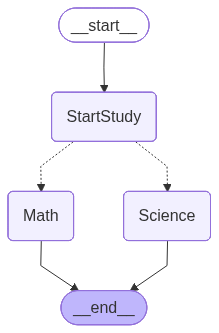

>>> StartStudy node triggered
>>> Science node triggered
{'student': 'Alice begins studying  Science', 'subject': 'Science'}


In [4]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from typing import Literal
import random
from IPython.display import Image, display

# Define state schema with Pydantic
class SubjectState(BaseModel):
    student: str
    subject: Literal["Math", "Science"]

# Node functions
def start_study(state: SubjectState):
    print(">>> StartStudy node triggered")
    return {"student": state.student + " begins studying "}

def math_node(state: SubjectState):
    print(">>> Math node triggered")
    return {"student": state.student + " Math", "subject": "Math"}

def science_node(state: SubjectState):
    print(">>> Science node triggered")
    return {"student": state.student + " Science", "subject": "Science"}

# Conditional routing
def decide_subject(state: SubjectState) -> Literal["Math", "Science"]:
    return "Math" if random.random() < 0.5 else "Science"

# Build graph
builder = StateGraph(SubjectState)
builder.add_node("StartStudy", start_study)
builder.add_node("Math", math_node)
builder.add_node("Science", science_node)
builder.add_edge(START, "StartStudy")
builder.add_conditional_edges("StartStudy", decide_subject)
builder.add_edge("Math", END)
builder.add_edge("Science", END)

pydantic_graph = builder.compile()

# Visualize + Run
display(Image(pydantic_graph.get_graph().draw_mermaid_png()))

# Invocation with valid input
print(pydantic_graph.invoke({"student": "Alice", "subject": "Math"}))


In [5]:
# Invocation with invalid input (subject not allowed)
print(pydantic_graph.invoke({"student": "Bob", "subject": "History"}))

ValidationError: 1 validation error for SubjectState
subject
  Input should be 'Math' or 'Science' [type=literal_error, input_value='History', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/literal_error